# 1. Khai báo thư viện và Tải dữ liệu

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Đọc dữ liệu từ file CSV
df = pd.read_csv('Mall_Customers.csv')

# 2. Kiểm tra thông tin tổng quan & Giá trị khuyết thiếu (Missing Values)

In [ ]:
# Xem 5 dòng đầu tiên
print("Dữ liệu 5 dòng đầu:")
display(df.head())

# Kiểm tra kiểu dữ liệu và giá trị thiếu
print("\nThông tin Dataset:")
df.info()

print("\nSố lượng giá trị bị trống ở mỗi cột:")
print(df.isnull().sum())

# Xem thống kê mô tả
print("\nBảng thống kê mô tả:")
display(df.describe())

# 3. Phân tích phân bố dữ liệu (Univariate Analysis)

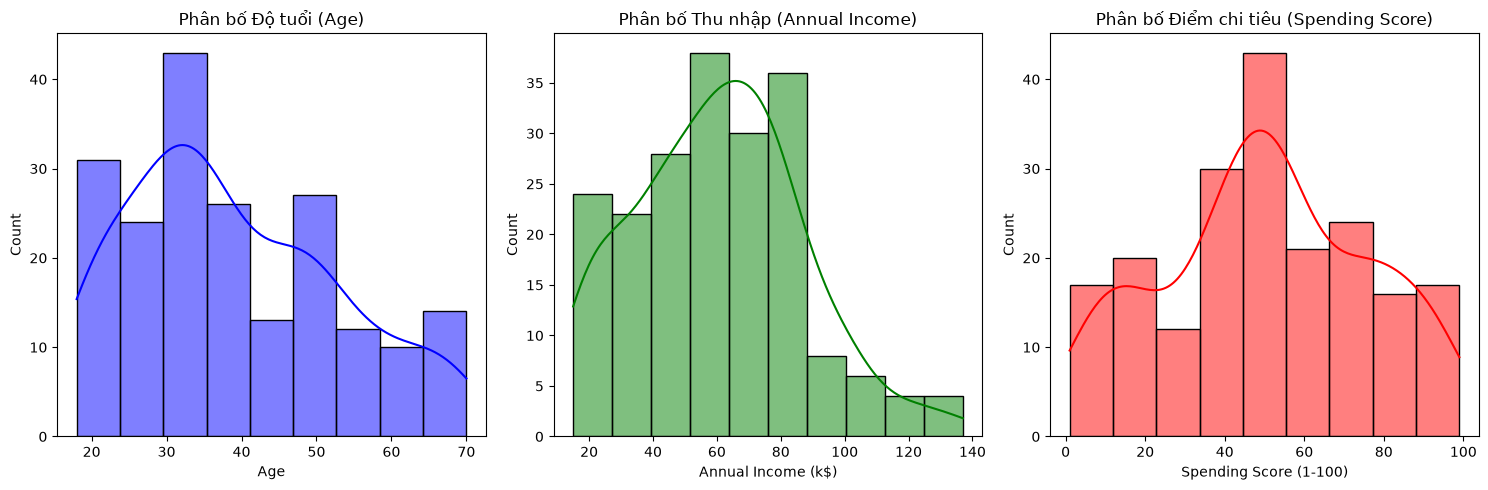

In [7]:
plt.figure(figsize=(15, 5))

# Biểu đồ 1: Phân bố Tuổi (Age)
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Phân bố Độ tuổi (Age)')

# Biểu đồ 2: Phân bố Thu nhập (Annual Income)
plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], kde=True, color='green')
plt.title('Phân bố Thu nhập (Annual Income)')

# Biểu đồ 3: Phân bố Điểm chi tiêu (Spending Score)
plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='red')
plt.title('Phân bố Điểm chi tiêu (Spending Score)')

plt.tight_layout()
plt.show()

# 4. Phân tích mối quan hệ giữa các biến (Bivariate Analysis)

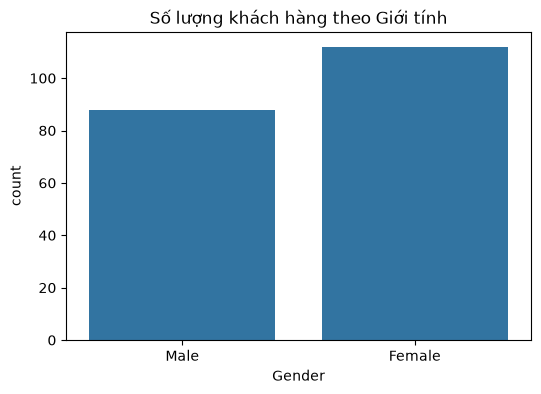

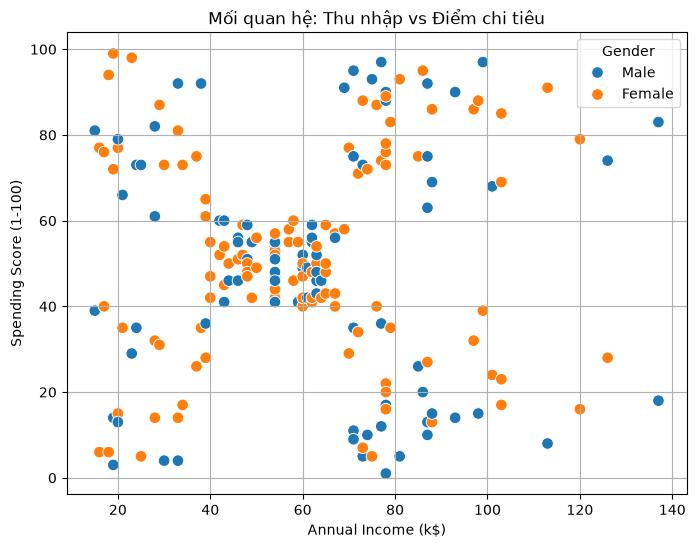

In [8]:
# 1. Tỷ lệ Giới tính (Gender)
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df)
plt.title('Số lượng khách hàng theo Giới tính')
plt.show()

# 2. Mối quan hệ giữa Thu nhập và Điểm chi tiêu
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df, s=70)
plt.title('Mối quan hệ: Thu nhập vs Điểm chi tiêu')
plt.grid(True)
plt.show()

# 5. Tiền xử lý dữ liệu & Chuẩn hóa (Preprocessing & Scaling)

In [ ]:
# 1. Loại bỏ cột CustomerID
df_clean = df.drop(columns=['CustomerID'])

# 2. Mã hóa thuộc tính Giới tính (Gender)
df_clean['Gender'] = df_clean['Gender'].map({'Female': 0, 'Male': 1})

# 3. Lưu thành file CSV sạch
df_clean.to_csv('Mall_Customers_Cleaned.csv', index=False)
print("Đã lưu thành công file Mall_Customers_Cleaned.csv!")

# 4. Chuẩn hóa dữ liệu bằng StandardScaler
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[features] = scaler.fit_transform(df_clean[features])

# 5. Xuất file dữ liệu đã chuẩn hóa
df_scaled.to_csv('Mall_Customers_Scaled.csv', index=False)
print("Đã lưu thành công file Mall_Customers_Scaled.csv!")